(0.0, 5.1)

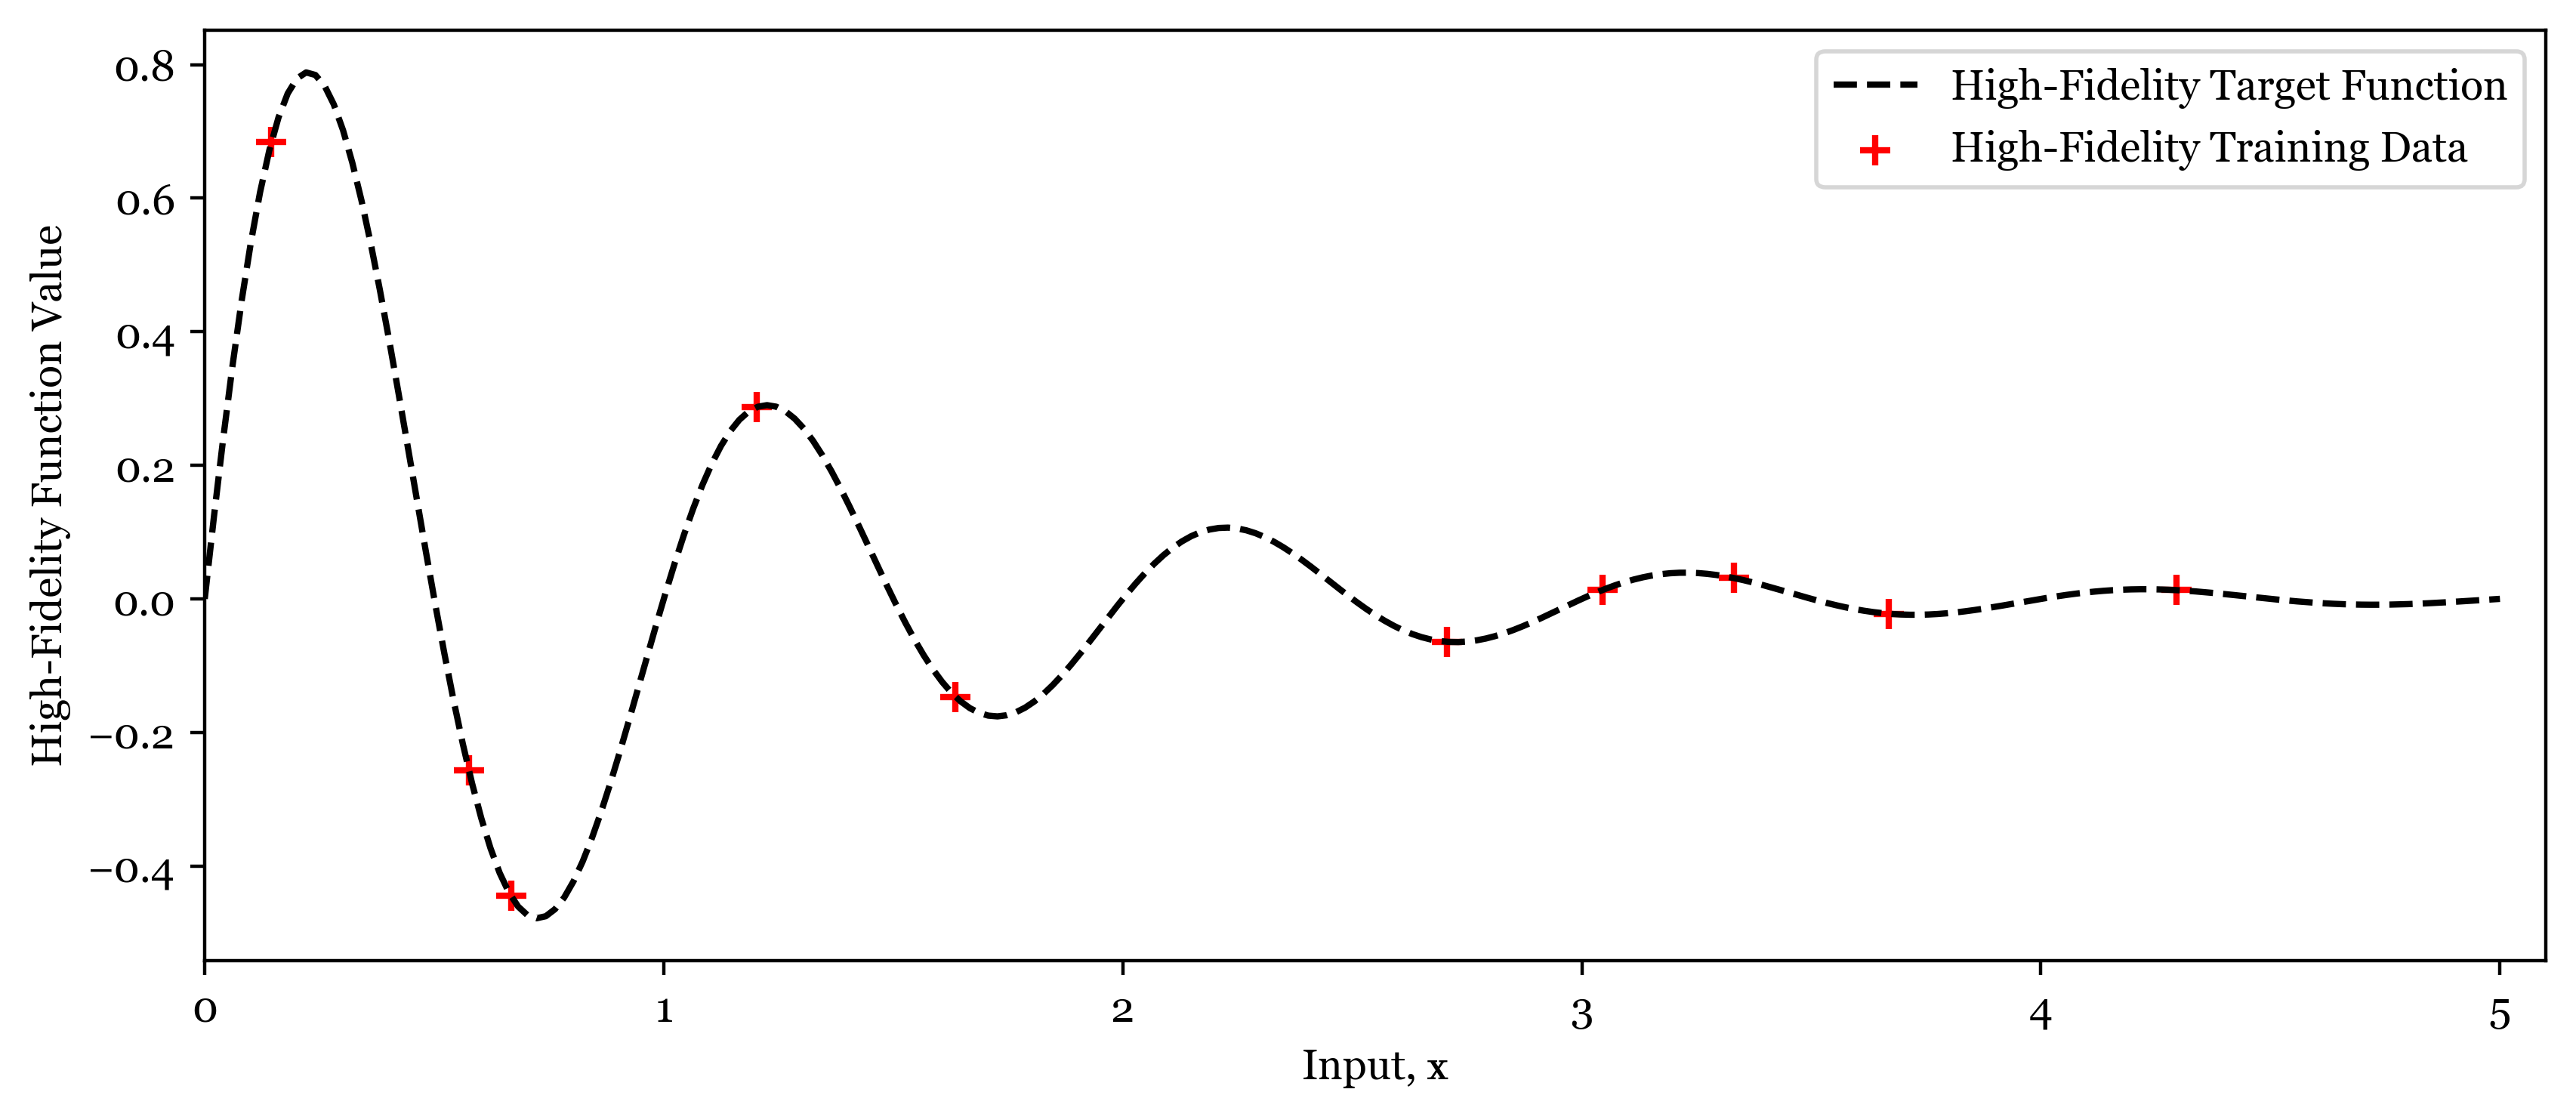

In [2]:
import sys
sys.path.append("..")   # add parent folder (project/) to Python path
from gplib.mf import *   # now absolute import worksimport math import math 
import matplotlib.pyplot as plt 

# Plot parameters 
plt.rcParams.update({
    "font.family": "georgia",
    'text.latex.preamble': r'\\usepackage{amsmath}',
    'mathtext.fontset': 'cm',
})
# Define number of fidelity-levels 
n_fidelities = 3 

# Define a list of sample sizes
sample_sizes = [10, 100, 250]

# Define the high and low-fidelity functions
funcs = [
    lambda x: np.exp(-x) * np.sin(2*math.pi*x), 
    lambda x: np.sin(2*math.pi*x),
    lambda x: np.exp(-x)
]

# Making some testing data 
Xtest = np.linspace(0.0, 5.0, 250).reshape(-1,1)

# Loading high-fidelity data
true_data = np.hstack((Xtest, funcs[0](Xtest)))

# Selecting optimal high-fidelity data
np.random.seed(43)
cutoff = 0.0
X_hf = np.random.uniform(cutoff, 5.0, size = sample_sizes[0]).reshape(-1,1)
hf_data = np.hstack((X_hf, funcs[0](X_hf)))

# Loading medium-fidelity data 
X_mf = np.random.uniform(0.0, 5.0, size = sample_sizes[1]).reshape(-1,1)
mf_data = np.hstack((X_mf, funcs[1](X_mf)))

# Loading low-fidelity data 
X_lf = np.random.uniform(0.0, 5.0, size = sample_sizes[2]).reshape(-1,1)
lf_data = np.hstack((X_lf, funcs[2](X_lf)))

# Creating a multi-fidelity-friendly data dictionary 
data_dict = {
    2:{
        'X':hf_data[:,0].reshape(-1,1),
        'Y':hf_data[:,1],
        'noise_var':1e-12,
        'var':np.var(hf_data[:,1]),
        'cost':100.0
    },
    1:{
        'X':mf_data[:,0].reshape(-1,1),
        'Y':mf_data[:,1],
        'noise_var':1e-12,
        'var':np.var(mf_data[:,1]),
        'cost':2.0
    },
    0:{
        'X':lf_data[:,0].reshape(-1,1),
        'Y':lf_data[:,1],
        'noise_var':1e-12,
        'var':np.var(lf_data[:,1]),
        'cost':1.0
    }
}


plt.figure(figsize=(10,4),dpi = 400)
plt.plot(Xtest.ravel(), funcs[0](Xtest).ravel(), linestyle = 'dashed', color = 'black', label = 'High-Fidelity Target Function')
plt.scatter(hf_data[:,0], hf_data[:,1], s = 50, marker = '+', color = 'red', label = 'High-Fidelity Training Data')

plt.xlabel("Input, $\mathbf{x}$")
plt.ylabel("High-Fidelity Function Value")
plt.legend()
plt.xlim([0,5.1])

In [2]:
np.corrcoef(funcs[0](Xtest).ravel(), funcs[2](Xtest.ravel()))

array([[1.        , 0.41729509],
       [0.41729509, 1.        ]])

In [3]:
# Instantiating the Hyperkriging model 
model = Hyperkriging(
    data_dict, RBF, Linear, max_cond = 1e5, epsilon = 1e-12
)

# Training GP-surrogate for lowest level of fidelity 
model.optimize(0, params = ['k_param', 'm_param', 'noise_var'], lr = 1e-2, epochs = 10000, beta1 = 0.9, beta2=0.999)

Calibrated white noise variance: 5.0394e-05
Calibrated white noise variance: 1.8656e-04
Calibrated white noise variance: 1.0001e-12


100%|██████████| 10000/10000 [00:48<00:00, 207.98it/s, Loss: -3.0698e+03]


In [4]:
model.optimize(1, params = ['k_param', 'm_param', 'noise_var'], lr = 1e-2, epochs = 10000, beta1 = 0.9, beta2=0.999)

100%|██████████| 10000/10000 [00:23<00:00, 420.12it/s, Loss: -9.3881e+02]


In [11]:
model.optimize(2, params = ['k_param', 'm_param', 'noise_var'], lr = 1e-1, epochs = 1000, beta1 = 0.9, beta2=0.999)

100%|██████████| 1000/1000 [00:01<00:00, 538.58it/s, Loss: -1.0483e+01]


In [13]:
# Instantiating the Hyperkriging model 
koh = KennedyOHagan(
    data_dict, RBF, Linear, max_cond = 1e5, epsilon = 1e-12
)

# Training GP-surrogate for lowest level of fidelity 
koh.optimize(0, params = ['k_param', 'm_param', 'rho', 'noise_var'], lr = 1e-1, epochs = 2000, beta1 = 0.9, beta2=0.999)

Calibrated white noise variance: 5.0394e-05
Calibrated white noise variance: 1.7614e-04
Calibrated white noise variance: 1.0001e-12


100%|██████████| 2000/2000 [00:09<00:00, 217.22it/s, Loss: -3.0688e+03]


In [15]:
koh.optimize(1, params = ['k_param', 'm_param', 'rho', 'noise_var'], lr = 1e-1, epochs = 5000, beta1 = 0.9, beta2=0.999)

100%|██████████| 5000/5000 [00:12<00:00, 414.35it/s, Loss: -9.5014e+02]


In [16]:
koh.optimize(2, params = ['k_param', 'm_param', 'rho', 'noise_var'], lr = 1e-1, epochs = 10000, beta1 = 0.9, beta2=0.999)

100%|██████████| 10000/10000 [00:19<00:00, 500.48it/s, Loss: -2.8786e+00]


In [17]:
# Instantiating the NARGP model 
nargp = NARGP(
    data_dict, RBF, Linear, max_cond = 1e5, epsilon = 1e-12
)

# Training GP-surrogate for lowest level of fidelity 
nargp.optimize(0, params = ['k_param', 'm_param', 'noise_var'], lr = 1e-1, epochs = 1000, beta1 = 0.9, beta2=0.999)

Calibrated white noise variance: 5.0394e-05
Calibrated white noise variance: 1.8656e-04
Calibrated white noise variance: 1.0001e-12


100%|██████████| 1000/1000 [00:04<00:00, 208.61it/s, Loss: -3.0670e+03]


In [18]:
nargp.optimize(1, params = ['k_param', 'm_param', 'noise_var'], lr = 1e-1, epochs = 5000, beta1 = 0.9, beta2=0.999)

100%|██████████| 5000/5000 [00:12<00:00, 409.08it/s, Loss: -9.4129e+02]


In [19]:
nargp.optimize(2, params = ['k_param', 'm_param', 'noise_var'], lr = 1e-1, epochs = 5000, beta1 = 0.9, beta2=0.999)

100%|██████████| 5000/5000 [00:09<00:00, 549.79it/s, Loss: -3.5050e+00]


In [20]:
kr_model = GP(data_dict[2]['X'], data_dict[2]['Y'], RBF, Linear, kernel_params = jnp.ones(2), noise_var = 1e-9, epsilon = 1e-8, max_cond = 1e5, calibrate=True)
optimizer = ADAM(kr_model, neg_mll, beta1=0.9, beta2=0.999)
optimizer.run(1e-1, 1000, ['k_param', 'm_param', 'noise_var'])

Calibrated white noise variance: 1.0000e-08


100%|██████████| 1000/1000 [00:01<00:00, 545.69it/s, Loss: 4.7610e-01]


{'noise_var': Array(-6.39228697, dtype=float64),
 'k_param': Array([-2.58140626, -2.71672442], dtype=float64),
 'm_param': Array([ 0.18845447, -0.06400631], dtype=float64)}

In [21]:
# Making the Hyperkriging predictions at the testing data 
hk_mean, hk_cov = model.predict(Xtest, 2, full_cov = False) 
hk_conf = 1.96 * np.sqrt(hk_cov)

In [22]:
# Making the Hyperkriging predictions at the testing data 
koh_mean, koh_cov = koh.predict(Xtest, 2) 
koh_conf = 1.96 * np.sqrt(np.diag(koh_cov))

In [23]:
# Making the Hyperkriging predictions at the testing data 
nargp_mean, nargp_cov = nargp.predict(Xtest, 2, full_cov = False) 
nargp_conf = 1.96 * np.sqrt(nargp_cov)

In [24]:
# Making the Hyperkriging predictions at the testing data 
kr_mean, kr_cov = kr_model.predict(Xtest, full_cov = False) 
kr_conf = 1.96 * np.sqrt(kr_cov)

(0.0, 5.0)

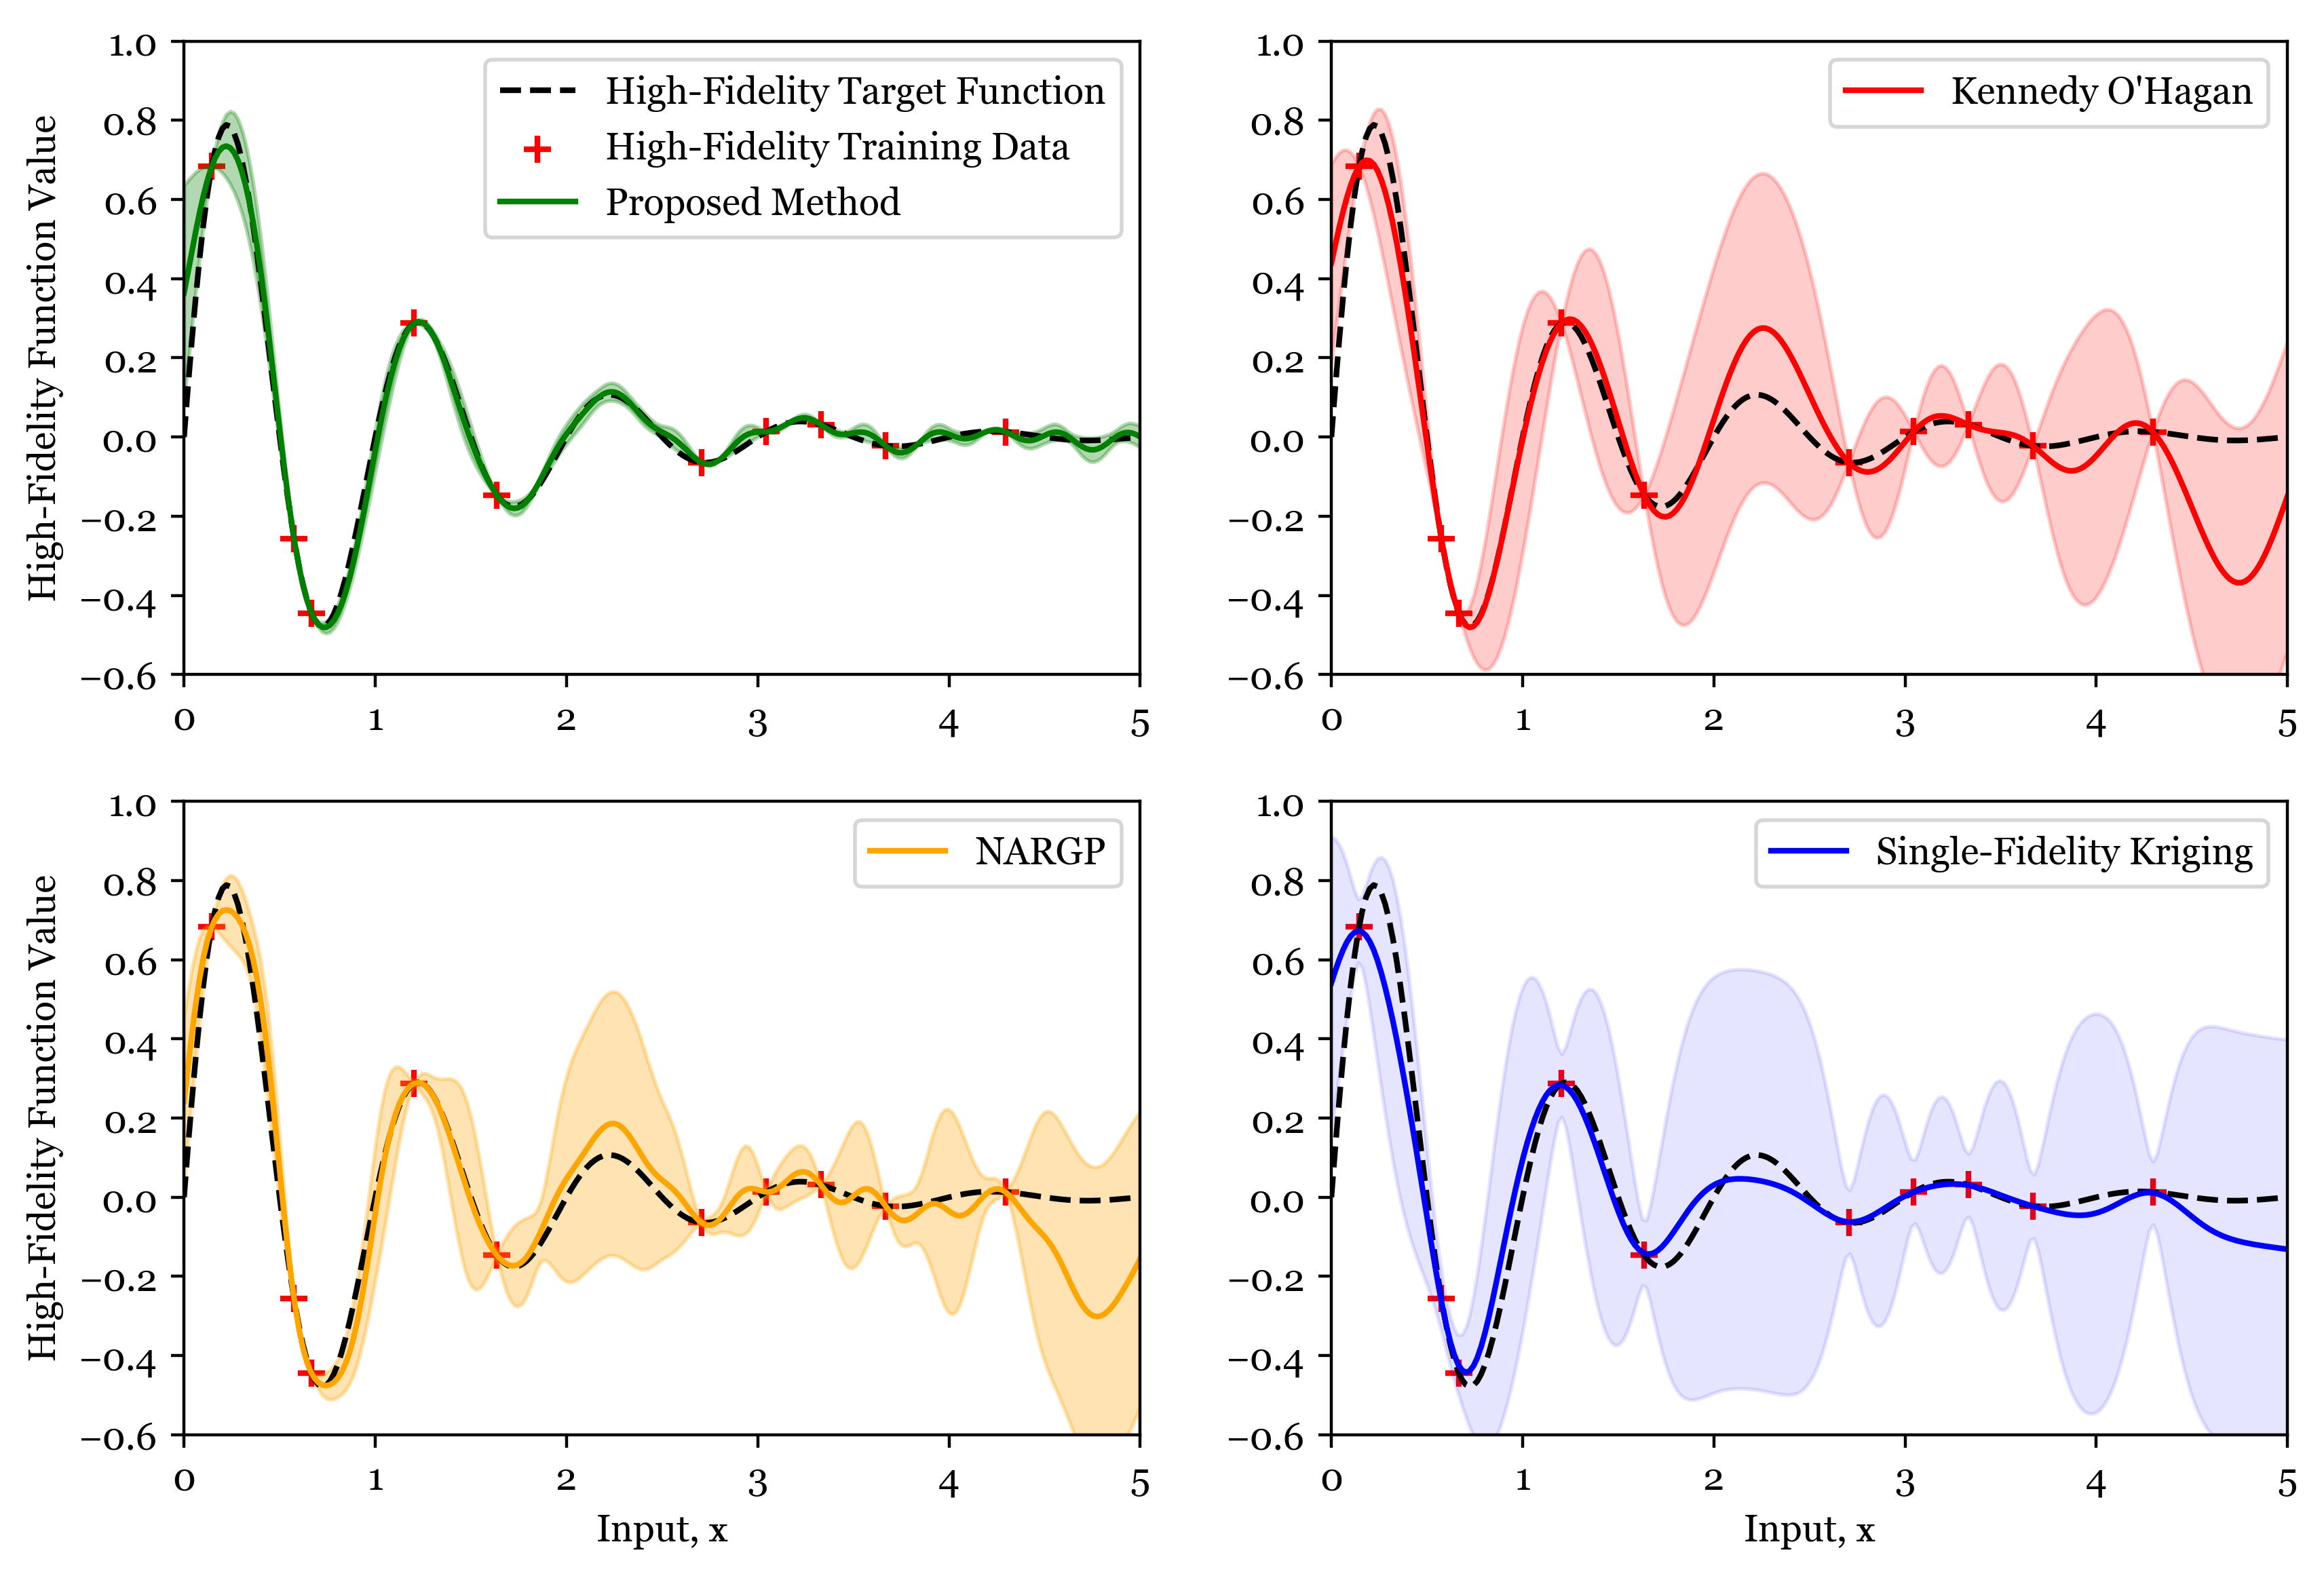

In [25]:
plt.figure(figsize=(10,6.67),dpi = 400)
plt.subplot(2,2,1)
plt.plot(Xtest.ravel(), funcs[0](Xtest).ravel(), linestyle = 'dashed', color = 'black', label = 'High-Fidelity Target Function')
plt.scatter(hf_data[:,0], hf_data[:,1], s = 50, marker = '+', color = 'red', label = 'High-Fidelity Training Data')
plt.plot(Xtest.ravel(), hk_mean.ravel(), color = 'green', label = "Proposed Method")
plt.fill_between(Xtest.ravel(), hk_mean.ravel() - hk_conf, hk_mean.ravel() + hk_conf, color = 'green', alpha = 0.3)
plt.ylabel("High-Fidelity Function Value")
plt.legend()
plt.ylim(-0.6, 1.0)
plt.xlim(0,5)

plt.subplot(2,2,2)
# Kennedy O'Hagan Prediction 
plt.plot(Xtest.ravel(), funcs[0](Xtest).ravel(), linestyle = 'dashed', color = 'black')
plt.scatter(hf_data[:,0], hf_data[:,1], s = 50, marker = '+', color = 'red')
plt.plot(Xtest.ravel(), koh_mean.ravel(), color = 'red', label = "Kennedy O'Hagan")
plt.fill_between(Xtest.ravel(), koh_mean.ravel() - koh_conf, koh_mean.ravel() + koh_conf, color = 'red', alpha = 0.2)
plt.legend()
plt.ylim(-0.6, 1.0)
plt.xlim(0,5)

plt.subplot(2,2,3)
# NARGP Prediction 
plt.plot(Xtest.ravel(), funcs[0](Xtest).ravel(), linestyle = 'dashed', color = 'black')
plt.scatter(hf_data[:,0], hf_data[:,1], s = 50, marker = '+', color = 'red')
plt.plot(Xtest.ravel(), nargp_mean.ravel(), color = 'orange', label = "NARGP")
plt.fill_between(Xtest.ravel(), nargp_mean.ravel() - nargp_conf, nargp_mean.ravel() + nargp_conf, color = 'orange', alpha = 0.3)
plt.legend()
plt.xlabel("Input, $\mathbf{x}$")
plt.ylabel("High-Fidelity Function Value")
plt.ylim(-0.6, 1.0)
plt.xlim(0,5)

# Kriging Prediction 
plt.subplot(2,2,4)
plt.plot(Xtest.ravel(), funcs[0](Xtest).ravel(), linestyle = 'dashed', color = 'black')
plt.scatter(hf_data[:,0], hf_data[:,1], s = 50, marker = '+', color = 'red')
plt.plot(Xtest.ravel(), kr_mean.ravel(), color = 'blue', label = "Single-Fidelity Kriging")
plt.fill_between(Xtest.ravel(), kr_mean.ravel() - kr_conf, kr_mean.ravel() + kr_conf, color = 'blue', alpha = 0.1)
plt.legend()
plt.xlabel("Input, $\mathbf{x}$")
plt.ylim(-0.6, 1.0)
plt.xlim(0,5)

In [28]:
from sklearn.metrics import mean_squared_error as MSE 
from scipy.linalg import cholesky, cho_solve
Ytest = funcs[0](Xtest).ravel()

print("Method           RMSE         R^2      log MLL")
print("--------------------------------------------------")
print("Proposed Method    & %.3e  &  %.4f  &  %.4f \\\\" % (np.sqrt(jnp.mean(hk_cov + (Ytest - hk_mean)**2)), np.corrcoef(Ytest.ravel(), hk_mean.ravel())[0,1], -neg_mll(model.d[2]['model'], model.d[2]['model'].p)))
print("Kennedy O'Hagan    & %.3e  &  %.4f  &  %.4f \\\\" % (np.sqrt(jnp.mean(koh_cov + (Ytest - koh_mean)**2)), np.corrcoef(Ytest.ravel(), koh_mean.ravel())[0,1], -delta_neg_mll(koh.d[2]['model'], koh.d[2]['model'].p)))
print("NARGP              & %.3e  &  %.4f  &  %.4f \\\\" % (np.sqrt(jnp.mean(nargp_cov + (Ytest - nargp_mean)**2)), np.corrcoef(Ytest.ravel(), nargp_mean.ravel())[0,1], -neg_mll(nargp.d[2]['model'], nargp.d[2]['model'].p)))
print("Kriging            & %.3e  &  %.4f  &  %.4f \\\\" % (np.sqrt(jnp.mean(kr_cov + (Ytest - kr_mean)**2)), np.corrcoef(Ytest.ravel(), kr_mean.ravel())[0,1], -neg_mll(kr_model, kr_model.p)))

Method           RMSE         R^2      log MLL
--------------------------------------------------
Proposed Method    & 4.419e-02  &  0.9848  &  10.4834 \\
Kennedy O'Hagan    & 1.225e-01  &  0.8820  &  2.8786 \\
NARGP              & 1.269e-01  &  0.9391  &  3.5094 \\
Kriging            & 1.988e-01  &  0.9241  &  -0.4755 \\
